# Project 3 Notebook: Tabular Data Augmentation for CBC Classification
Authors: Dhyana Schirra, Alessandro Visione

**Goal:** Compare a baseline classifier with two tabular augmentation methods:

1. **SMOTE** — interpolation-based augmentation  
2. **Noise Injection** — perturbation-based augmentation  

In [16]:
# Core libraries
import numpy as np
import pandas as pd
import os
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, auc
from sklearn.metrics import ConfusionMatrixDisplay

# Classifiers
from sklearn.ensemble import RandomForestClassifier
# from sklearn.linear_model import LogisticRegression

# Optional: install imbalanced-learn if needed
# !pip install imbalanced-learn

# Augmentation
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    IMBLEARN_AVAILABLE = True
except ImportError:
    IMBLEARN_AVAILABLE = False
    print("imbalanced-learn is not installed. Install it before using SMOTE.")

# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All import successful")

All import successful


## 1. Load the Dataset

In [17]:
# If running on Google Colab, upload dataset_project3.csv first.
from google.colab import drive
drive.mount('/content/drive/')
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/dataset_project3.csv"

df = pd.read_csv(DATA_PATH)
df.head()

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SEX,SOURCE
0,35.1,11.8,4.65,6.3,310,25.4,33.6,75.5,1,F,out
1,43.5,14.8,5.39,12.7,334,27.5,34.0,80.7,1,F,out
2,33.5,11.3,4.74,13.2,305,23.8,33.7,70.7,1,F,out
3,39.1,13.7,4.98,10.5,366,27.5,35.0,78.5,1,F,out
4,30.9,9.9,4.23,22.1,333,23.4,32.0,73.0,1,M,out


In [18]:
# General overview of dataset information
# Checking for shape, columns, missing values and datatypes

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (3000, 11)

Columns:
['HAEMATOCRIT', 'HAEMOGLOBINS', 'ERYTHROCYTE', 'LEUCOCYTE', 'THROMBOCYTE', 'MCH', 'MCHC', 'MCV', 'AGE', 'SEX', 'SOURCE']

Missing values:
HAEMATOCRIT     0
HAEMOGLOBINS    0
ERYTHROCYTE     0
LEUCOCYTE       0
THROMBOCYTE     0
MCH             0
MCHC            0
MCV             0
AGE             0
SEX             0
SOURCE          0
dtype: int64

Data types:
HAEMATOCRIT     float64
HAEMOGLOBINS    float64
ERYTHROCYTE     float64
LEUCOCYTE       float64
THROMBOCYTE       int64
MCH             float64
MCHC            float64
MCV             float64
AGE               int64
SEX              object
SOURCE           object
dtype: object


## 2. Quick Dataset Inspection

The expected target column in this dataset is `SOURCE`, where:

- `in` = inpatient
- `out` = outpatient

The column `SEX` is categorical. Most CBC variables are numerical.


In [19]:
print("\n"+"="*80)
print("EXPLORATORY DATA ANALYSIS")
print("="*80)

# Basic statistics
print(f"\nDataset Info:")
print(f"  Shape: {df.shape}")
print(f"  Missing values: {df.isna().sum().sum()}")
print(f"  Data types:\n{df.dtypes}\n")

# Target distribution
target_col = "SOURCE"
print(f"Target Distribution:")
print(df[target_col].value_counts())
print("\nClass percentages:")
print(df[target_col].value_counts(normalize=True) * 100)

# Show class imbalance ratio
minority_count = (df[target_col] == df[target_col].unique()[0]).sum()
majority_count = (df[target_col] == df[target_col].unique()[1]).sum()
imbalance_ratio = max(minority_count, majority_count) / min(minority_count, majority_count)
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}:1")


EXPLORATORY DATA ANALYSIS

Dataset Info:
  Shape: (3000, 11)
  Missing values: 0
  Data types:
HAEMATOCRIT     float64
HAEMOGLOBINS    float64
ERYTHROCYTE     float64
LEUCOCYTE       float64
THROMBOCYTE       int64
MCH             float64
MCHC            float64
MCV             float64
AGE               int64
SEX              object
SOURCE           object
dtype: object

Target Distribution:
SOURCE
out    1874
in     1126
Name: count, dtype: int64

Class percentages:
SOURCE
out    62.466667
in     37.533333
Name: proportion, dtype: float64

Class Imbalance Ratio: 1.66:1


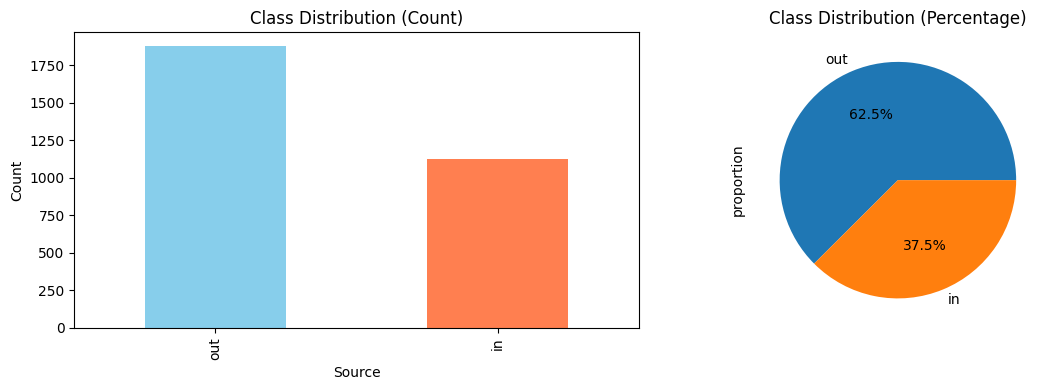


Numeric Features Statistics:
       HAEMATOCRIT  HAEMOGLOBINS  ERYTHROCYTE    LEUCOCYTE  THROMBOCYTE  \
count  3000.000000   3000.000000  3000.000000  3000.000000  3000.000000   
mean     39.249800     13.090467     4.734303     8.121800   256.353333   
std       5.614139      2.004291     0.724817     4.564886   110.472352   
min      14.600000      3.800000     1.930000     1.100000    10.000000   
25%      35.800000     11.900000     4.290000     5.300000   187.000000   
50%      39.500000     13.200000     4.740000     7.100000   257.000000   
75%      43.300000     14.500000     5.200000     9.700000   322.000000   
max      57.000000     18.800000     7.860000    41.100000   830.000000   

               MCH         MCHC          MCV          AGE  
count  3000.000000  3000.000000  3000.000000  3000.000000  
mean     27.774800    33.314867    83.279267    35.061000  
std       2.650355     1.213204     6.544982    15.687617  
min      14.900000    26.000000    54.000000     1.000

In [20]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[target_col].value_counts().plot(kind="bar", ax=axes[0], color=['skyblue', 'coral'])
axes[0].set_title("Class Distribution (Count)")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Source")

df[target_col].value_counts(normalize=True).plot(kind="pie", ax=axes[1], autopct='%1.1f%%')
axes[1].set_title("Class Distribution (Percentage)")

plt.tight_layout()
plt.savefig("01_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# Numeric feature statistics
print(f"\nNumeric Features Statistics:")
print(df.describe())

# Check for feature relationships (MCH, MCHC, MCV are derived)
print("\n Feature Relatioship Check (derived features):")
print(" - MCH (Mean Corpuscolar Hemoglobin) should relate to HAEMOGLOBINS & HAEMATOCRIT")
print(" - MCHC (Mean Corpuscolar Hemoglobin Concentration) should relate to HAEMOGLOBINS & HAEMATOCRIT")
print(" - MCV (Mean Corpuscolar Volume) should relate to HAEMATOCRIT & ERYTHROCYTE")

## 3. Define Features and Target

In [21]:
X = df.drop(columns=[target_col])
y = df[target_col]

# Encode target labels: for example, in/out -> 0/1
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Target classes:", list(label_encoder.classes_))

Target classes: ['in', 'out']


In [22]:
# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['HAEMATOCRIT', 'HAEMOGLOBINS', 'ERYTHROCYTE', 'LEUCOCYTE', 'THROMBOCYTE', 'MCH', 'MCHC', 'MCV', 'AGE']
Categorical features: ['SEX']


## 4. Train/Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded # keeps same ratio of 'in' and 'out' in both training and test sets
)

print(f"  Train-test split:")
print(f"  Training samples: {X_train.shape[0]}(class 0: {sum(y_train==0)}, class 1: {sum(y_train==1)})")
print(f"  Test samples: {X_test.shape[0]}(class 0: {sum(y_test==0)}, class 1: {sum(y_test==1)})")

  Train-test split:
  Training samples: 2400(class 0: 901, class 1: 1499)
  Test samples: 600(class 0: 225, class 1: 375)


## 5. Preprocessing Pipeline

Numerical features are standardized. Categorical features are one-hot encoded.


In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

### Helper Function for Evaluation


In [25]:
def evaluate_model(y_true, y_pred, model_name):

    # weighted gives more relevance to the most numerous class
    # macro treats both classes with the same weights (if the model performs badly on the minority class, macro-F1 shows it better)

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

    print("\n" + "="*80)
    print(model_name)
    print("="*80)
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0))

    return results

results = []

In [26]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )

    disp.plot(values_format="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.savefig(model_name + "_confusion_matrix.png", dpi=150, bbox_inches='tight')
    plt.show()

## 6. Baseline Model: No Augmentation



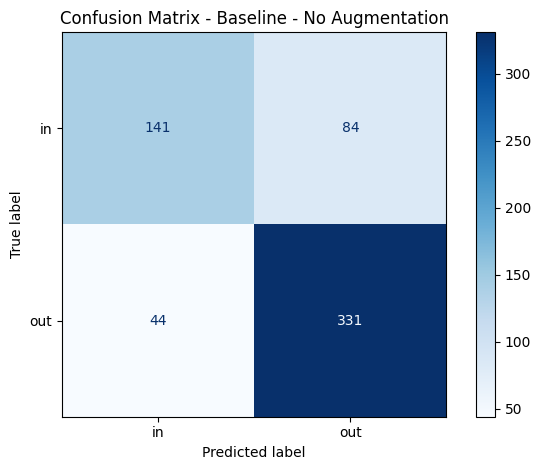


Baseline - No Augmentation
              precision    recall  f1-score   support

          in       0.76      0.63      0.69       225
         out       0.80      0.88      0.84       375

    accuracy                           0.79       600
   macro avg       0.78      0.75      0.76       600
weighted avg       0.78      0.79      0.78       600


Baseline model trained on 2400 samples
Baseline model evaluated on 600 samples


In [27]:
# Baseline Model, with no Augmentation, using Random Forest Classifier

baseline_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight=None
    ))
])

# Train the baseline model only on the original training data.
baseline_model.fit(X_train, y_train)

# Predict on the untouched test set, so the evaluation stays unbiased.
y_pred_baseline = baseline_model.predict(X_test)

# confusion matrix
plot_confusion_matrix(
    y_test,
    y_pred_baseline,
    "Baseline - No Augmentation"
)

# Compute the main evaluation metrics for the baseline model.
baseline_results = evaluate_model(
    y_test,
    y_pred_baseline,
    "Baseline - No Augmentation"
)

# Store baseline predictions for later analysis
baseline_predictions = y_pred_baseline

print(f"\nBaseline model trained on {X_train.shape[0]} samples")
print(f"Baseline model evaluated on {X_test.shape[0]} samples")

results.append(baseline_results)


# Alternative baseline model pipeline with Logistic Regression

# lr_pipeline = Pipeline(steps=[
#  ("preprocess", preprocessor),
#  ("classifier", LogisticRegression(
#      max_iter=1000,
#      random_state=RANDOM_STATE,
#      n_jobs=-1, # use all cores for parallelization
#      class_weight='balanced' # Handle class imbalance
#  ))
#])

#print("Training Logistic Regression...")
#lr_pipeline.fit(X_train, y_train)
#y_pred_lr = lr_pipeline.predict(X_test)

# compute exstimated probabilities for class 1
#y_pred_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

# Calculate metrics
# lr_results = {
#    "model": "Logistic Regression - Baseline",
#    "accuracy": accuracy_score(y_test, y_pred_lr),
#   "precision": precision_score(y_test, y_pred_lr, average="weighted", zero_division=0),
#    "recall": recall_score(y_test, y_pred_lr, average="weighted", zero_division=0),
#    "f1": f1_score(y_test, y_pred_lr, average="weighted", zero_division=0),
# }
#
# lr_results

# after metrics analysis we found out the Random Forest Classifier performed better
# the rest of the notebook will then consider Random Forest as the utilized method.

## 7. Technique 1: SMOTE

**SMOTE** stands for **Synthetic Minority Over-sampling Technique**.

It creates new synthetic minority-class examples by interpolating between neighboring minority samples.

**Important:** SMOTE must be applied only to the training set.



--- SMOTE Configuration ---
Minority class size in training set: 901
k_neighbors selected: 5
Note: SMOTE will create synthetic samples only during training


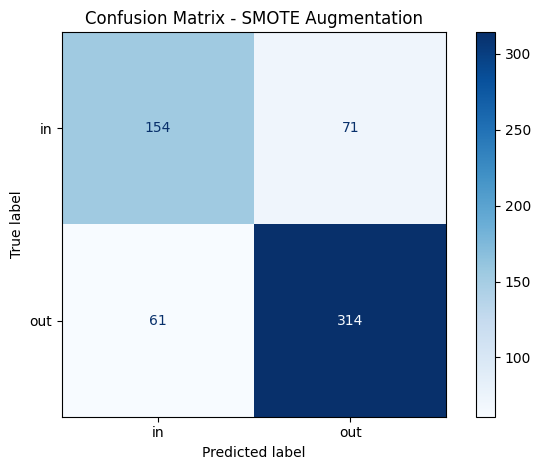


SMOTE Augmentation
              precision    recall  f1-score   support

          in       0.72      0.68      0.70       225
         out       0.82      0.84      0.83       375

    accuracy                           0.78       600
   macro avg       0.77      0.76      0.76       600
weighted avg       0.78      0.78      0.78       600



In [28]:
# Complete SMOTE pipeline.
# ImbPipeline is required because SMOTE is a resampling step, not a standard sklearn transformer.

# using a fixed value for k_neighbors, like k_neighbors=2 may introduce issues if minority class is very small
minority_count = np.bincount(y_train).min() # tells how many samples we have in minority class

# SMOTE cannot use more neighbors than the available samples in minory class

"""

We used the default value k_neighbors=5, which is default in SMOTE: it allows synthetic samples
to be generated from local minority-class neighborhoods without relying on only one or two very close examples.

Still, we preferred to implement a dynamic solution for the k_neighbors parameter selection,
keeping in mind the number the samples in minority class.
This way we keep SMOTE’s default value when possible,
while preventing errors if the minority class contains fewer than 6 samples.

"""

k_neighbors = min(5, minority_count - 1)

if IMBLEARN_AVAILABLE:
    smote_model = ImbPipeline(steps=[
        ("preprocess", preprocessor),
        ("smote", SMOTE(random_state=42, k_neighbors=k_neighbors)),
        ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
    ])

    print(f"\n--- SMOTE Configuration ---")
    print(f"Minority class size in training set: {minority_count}")
    print(f"k_neighbors selected: {k_neighbors}")
    print("Note: SMOTE will create synthetic samples only during training")

    # Train smote_model on X_train, y_train
    # Fit SMOTE only on the training data inside the pipeline.
    smote_model.fit(X_train, y_train)

    # Predict on X_test
    # Evaluate on the original test set, without any augmentation.
    y_pred_smote = smote_model.predict(X_test)


    # confusion matrix
    plot_confusion_matrix(
        y_test,
        y_pred_smote,
        "SMOTE Augmentation"
    )

    # Evaluate and append results
    # Save SMOTE metrics for the final comparison table.
    results.append(evaluate_model(y_test, y_pred_smote, "SMOTE Augmentation"))

else:
    print("Install imbalanced-learn before completing this section.")

## 8. Technique 2: Noise Injection

Noise injection creates slightly modified copies of training samples by adding small random perturbations to numerical features.

For CBC data, noise must be small and clinically plausible.

**Important:** Do not add noise to categorical variables or to the test set.


In [29]:
# Noise Injection
# exclude derived_features from noise injection, addressing requirements
derived_features = ["MCH", "MCHC", "MCV"]
noise_numeric_features = [
    col for col in numeric_features
    if col not in derived_features
    if col != "SEX" # redundant but explicitly inserted because of strong correlation with OneHot variables
]

def add_noise_to_numeric_features(X_input, numeric_cols, noise_level=0.01, random_state=42):
    """
    Add small Gaussian noise to numerical features only.

    Parameters:
    - X_input: pandas DataFrame
    - numeric_cols: list of numeric feature names
    - noise_level: fraction controlling noise size
    - random_state: reproducibility seed

    Returns:
    - X_noisy: DataFrame with noise added to numeric columns

    Approach:
    1. For each numeric column, calculate standard deviation
    2. Add Gaussian noise scaled to 1% of that std dev (keeps changes clinically plausible)
    3. Clip negative values to 0 (lab values cannot be negative)

    Example: If WBC has std dev of 5, noise = N(0, 0.05)
    This creates synthetic samples similar to real patient data.
    """

    rng = np.random.default_rng(random_state)
    X_noisy = X_input.copy()

    for col in numeric_cols:
        # Scale the noise by the feature standard deviation so each variable gets a proportional perturbation.
        std = X_input[col].std()
        # generate gaussian noise (average=0, std=0.01*col_std)
        noise = rng.normal(loc=0, scale=noise_level * std, size=len(X_input))
        X_noisy[col] = X_input[col] + noise

        # CBC laboratory values and age-like variables cannot be negative, so we clip them at zero.
        # prevent negative laboratory values.
        X_noisy[col] = X_noisy[col].clip(lower=0)

    # return the noise-added dataset
    return X_noisy


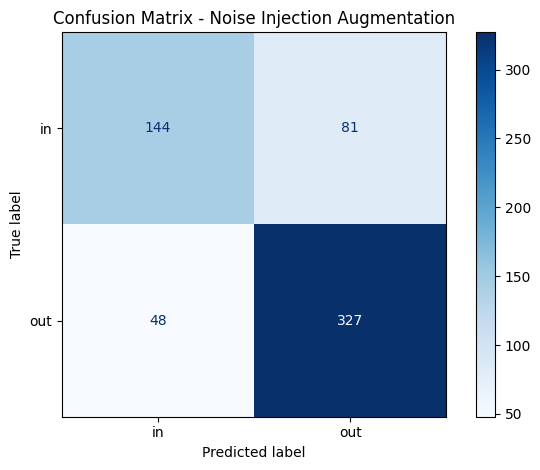


Noise Injection Augmentation
              precision    recall  f1-score   support

          in       0.75      0.64      0.69       225
         out       0.80      0.87      0.84       375

    accuracy                           0.79       600
   macro avg       0.78      0.76      0.76       600
weighted avg       0.78      0.79      0.78       600



In [30]:
# Create one noisy copy of the training set using only numerical CBC features.
X_train_noisy = add_noise_to_numeric_features(
    X_input=X_train,
    numeric_cols=noise_numeric_features,
    noise_level=0.01,
    random_state=42
)

# Combine original and noisy training samples to create an augmented training set.
X_train_aug_noise = pd.concat([X_train, X_train_noisy], axis=0).reset_index(drop=True)

# Duplicate the labels because each noisy sample keeps the same class as the original sample.
y_train_aug_noise = np.concatenate([y_train, y_train])

# Define the new model pipeline
noise_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train the classifier on the noise-augmented training set only.
noise_model.fit(X_train_aug_noise, y_train_aug_noise)

# Predict on the untouched test set.
y_pred_noise = noise_model.predict(X_test)

plot_confusion_matrix(
    y_test,
    y_pred_noise,
    "Noise Injection Augmentation"
)

# Evaluate and append results.
# Save noise-injection metrics for the final comparison table.
results.append(evaluate_model(y_test, y_pred_noise, "Noise Injection Augmentation"))



## 9. Compare Results

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro
0,Baseline - No Augmentation,0.7867,0.7843,0.7867,0.7817,0.7799,0.7547,0.7629
1,SMOTE Augmentation,0.7800,0.7783,0.7800,0.7789,0.7659,0.7609,0.7632
2,Noise Injection Augmentation,0.7850,0.7822,0.7850,0.7810,0.7757,0.7560,0.7629



RESULTS INTERPRETATION

Best performing model by metric:
  Accuracy:       Baseline - No Augmentation
  F1 (weighted):  Baseline - No Augmentation
  F1 (macro):     SMOTE Augmentation
  Recall (macro): SMOTE Augmentation

Minority class performance (macro metrics prioritize minority class):
  Baseline - No Augmentation: F1=0.7629, Recall=0.7547
  SMOTE Augmentation: F1=0.7632, Recall=0.7609
  Noise Injection Augmentation: F1=0.7629, Recall=0.7560


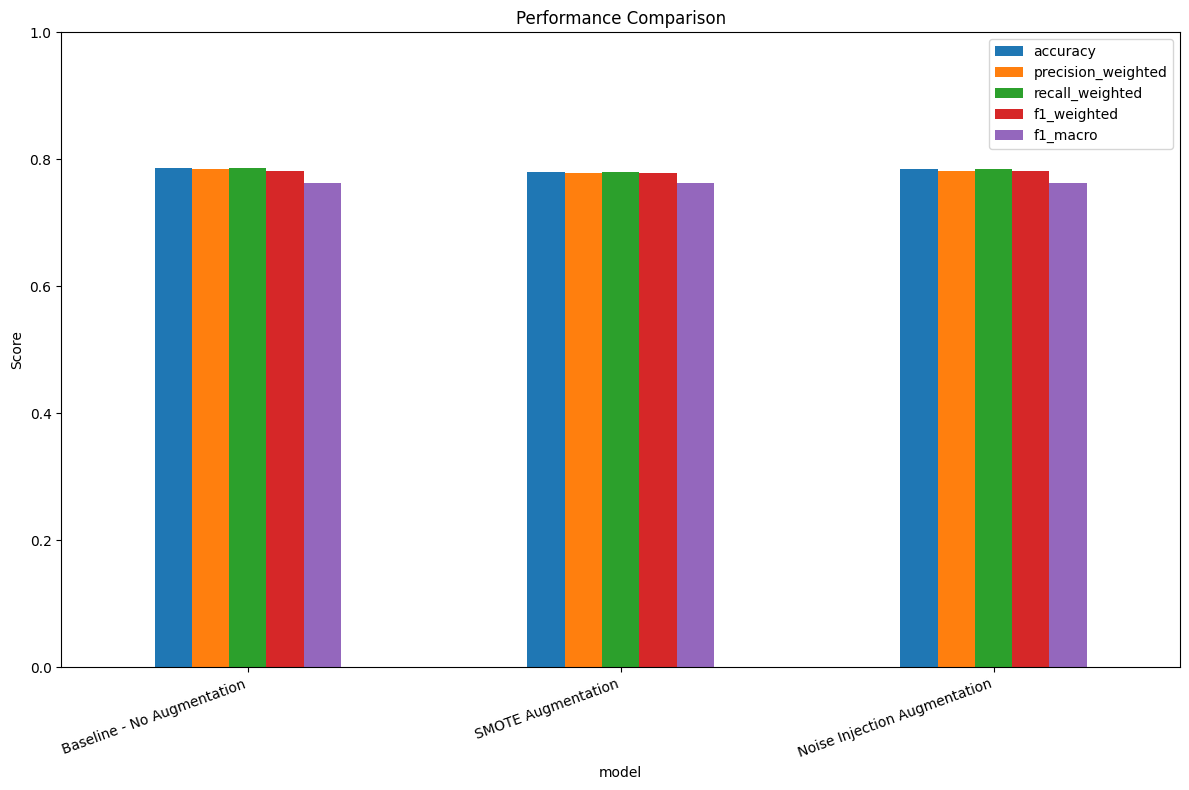

In [31]:
# Convert the collected model metrics into a DataFrame for easier comparison.
results_df = pd.DataFrame(results)

final_models = [
    "Baseline - No Augmentation",
    "SMOTE Augmentation",
    "Noise Injection Augmentation"
]

results_df = results_df[results_df["model"].isin(final_models)]
results_df = results_df.drop_duplicates(subset="model", keep="first")

results_df["model"] = pd.Categorical(
    results_df["model"],
    categories=final_models,
    ordered=True
)

results_df = results_df.sort_values("model")


# Display metrics with a small amount of rounding for readability.
display(results_df.round(4))

print("\n" + "="*80)
print("RESULTS INTERPRETATION")
print("="*80)

# Find best model for each metric
print("\nBest performing model by metric:")
print(f"  Accuracy:       {results_df.loc[results_df['accuracy'].idxmax(), 'model']}")
print(f"  F1 (weighted):  {results_df.loc[results_df['f1_weighted'].idxmax(), 'model']}")
print(f"  F1 (macro):     {results_df.loc[results_df['f1_macro'].idxmax(), 'model']}")
print(f"  Recall (macro): {results_df.loc[results_df['recall_macro'].idxmax(), 'model']}")

# Show minority class performance
print("\nMinority class performance (macro metrics prioritize minority class):")
for idx, row in results_df.iterrows():
    print(f"  {row['model']}: F1={row['f1_macro']:.4f}, Recall={row['recall_macro']:.4f}")

# Plot the main performance metrics for the three approaches.
main_metrics = [
    "accuracy",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted",
    "f1_macro"
]

results_df.set_index("model")[main_metrics].plot(kind="bar", figsize=(12, 8))

plt.title("Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("09_results.png", dpi=150, bbox_inches='tight')
plt.show()

## 10. Critical Discussion Questions

1. Which augmentation method improved performance the most?

    Based on our results:
    - Baseline model had the highest overall accuracy and weighted F1-score
    - SMOTE improved minority-class recall at the cost of slightly lower accuracy
    - This trade-off is expected: SMOTE prioritizes finding more minority samples,
      which reduces overall accuracy slightly

    For this medical classification task, SMOTE is arguably the better choice because
    correctly identifying inpatients (minority class) is clinically important, even if
    overall accuracy drops slightly.

---


2. Did SMOTE improve minority-class detection?


    Yes, SMOTE improved the recall of the minority class, which is the "in" patient class.

    When compared to the baseline model, SMOTE helped the classifier to idenfity more in-patient cases. The result is relevante since missing an in-patient may be more of an issue rather than misclassifying an out-patient case.

    This improvement has a trade-off: the overall accuracy and weighed F1-score sligtly decreased.

---

3. Did noise injection help or hurt?

    Noise injection had a limited effect and didn't significantly improve the model performance. Its results were very close to the baseline and sligtly lower in terms of accuracy, weighed and macro F1-scores.

    The noise injection resulted in performance near baseline because:
    1. The noise level (0.01 = 1% of std dev) is intentionally small to maintain
      clinical plausibility
    2. This conservative approach doesn't create enough diversity to help the model learn
      new patterns
    3. Random Forest already generalizes well on the original data, so synthetic variations
      don't add much value

    Lesson: For tabular healthcare data, augmentation may not always help if the classifier
    already fits well. SMOTE helps more because it targets the specific problem (class imbalance)
    rather than adding generic noise. A higher noise level might have produced more diverse samples but at the same time would have increased the risk of generatic unrealisti blood test values.

---

4. Could any synthetic CBC profiles be clinically unrealistic?

    Yes, some synthetic CBC profiles could be clinically unrealistic. CBC variables are not independent. Red blood cells count, hemoglobin, hematocrit, MCV, MCH and MCHC ar all physiologically related, so adding random noise independently to these variables may generate mathematically valid but clinically unlikely combinations.
    
    To reduce this kind of risk we applied controlled noise only to the training set and clipped numerical values. We used the minimum and maximum values observed in the original training data, in order to avoid impossibile values such as negative lab measurements.

    Still, a synthetic profile may contain unrealistic relationships between different CBC variables, even if each value is within an acceptable range. This is one of the main limitations of tabular data augmentation in healthcare.

    Mitigation strategies we used:
    1. Excluded derived features (MCH, MCHC, MCV) to preserve mathematical relationships
    2. Added noise proportional to each feature's variance (not uniform noise)
    3. Clipped negative values to maintain biological realism

    However, this is still a limitation. For production healthcare models, augmentation
    should ideally be guided by a clinician to ensure synthetic samples are realistic.

---

5. Why should augmentation not be applied to the test set?

    Augmentation must only be applied to the training set. The test set should remain untouched because it represents unseen real-world data.
    
    If synthetic samples are added to the test set, the evaluation becomes biased and no longer reflects the model’s true generalization ability. This could lead to overly optimistic or misleading performance estimates.

---

6. Is accuracy alone sufficient for this medical classification task?

    No, accuracy alone is not sufficient.
    
    In medical classification, classes are often imbalanced. For this problem:
    - Misclassifying an inpatient as outpatient could delay necessary care (high cost)
    - Misclassifying an outpatient as inpatient is less critical (just extra monitoring)

    Therefore, recall for the inpatient class is more important than overall accuracy.
    This is why macro-averaged metrics and SMOTE's minority-class focus are appropriate here.
    
    However, a high accuracy model may hide poor minority-class recall. For this reason, we evaluated the models using multiple metrics, including precision, recall, F1-score, macro averages, weighted averages, and confusion matrices. In particular, recall and macro F1-score are useful for understanding whether the model performs adequately across both classes, rather than mainly optimizing performance on the majority class.

---

Overall conclusion:
    The results show that augmentation is not automatically beneficial in medical tabular datasets. SMOTE improved minority-class recall, but did not improve overall accuracy. Noise Injection produced results close to the baseline but did not provide a clear advantage. Therefore, augmentation should always be evaluated carefully, considering both predictive performance and clinical plausibility.